In [1]:
import sys
sys.path.append("..")
from qiskit.quantum_info import SparsePauliOp
from qiskit import QuantumCircuit
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from numbers import Number
from qiskit.synthesis import LieTrotter
import numpy as np
import scipy as scipy

### State preparation with 1 ancilla and 2 excitations on a total of 35 qubits

In [2]:
# 2 exc
# def prep_psi_0(qc: QuantumCircuit):
#     qc.cx(34, 10)
#     qc.cx(34, 31)
#     return qc


# def prep_psi_0_by_0(qc: QuantumCircuit):
#     qc.cx(34, 10, ctrl_state="0")
#     qc.cx(34, 31, ctrl_state="0")
#     return qc

# def prep_psi_0(qc: QuantumCircuit):
#     qc.cx(34, 14)
#     qc.cx(34, 20)
#     return qc


# def prep_psi_0_by_0(qc: QuantumCircuit):
#     qc.cx(34, 14, ctrl_state="0")
#     qc.cx(34, 20, ctrl_state="0")
#     return qc

# 4 exc
def prep_psi_0(qc: QuantumCircuit):
    qc.cx(33, 0)
    qc.cx(33, 14)
    qc.cx(34, 13)
    qc.cx(34, 25)
    return qc


def prep_psi_0_by_0(qc: QuantumCircuit):
    qc.cx(33, 0, ctrl_state="0")
    qc.cx(33, 14,ctrl_state="0")
    qc.cx(34, 13,ctrl_state="0")
    qc.cx(34, 25, ctrl_state="0")
    return qc

### Test if state prep works as expected

In [3]:
from qiskit_aer import StatevectorSimulator
from qiskit_aer.primitives import SamplerV2

# sv = StatevectorSimulator()
sampler = SamplerV2(options={"backend_options": {"method": "matrix_product_state"}})
qc = QuantumCircuit(35)
#qc.h(34)
#qc.h(35)
#qc.h(36)
qc.h(33)
qc.h(34)
qc = prep_psi_0(qc)
qc.measure_all()

job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'00000000000000000000000000000000000': 245,
 '10000000010000000000010000000000000': 267,
 '01000000000000000000100000000000001': 259,
 '11000000010000000000110000000000001': 253}

In [4]:
qc = QuantumCircuit(35)
#qc.h(34)
#qc.h(35)
#qc.h(36)
qc.h(33)
qc.h(34)
qc = prep_psi_0(qc)
qc = prep_psi_0_by_0(qc)
qc.measure_all()
job = sampler.run([qc])
res = job.result()

res[0].data.meas.get_counts()

{'10000000010000000000110000000000001': 258,
 '01000000010000000000110000000000001': 260,
 '11000000010000000000110000000000001': 244,
 '00000000010000000000110000000000001': 262}

## Hardware experiments

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService(name='algolab')
backend= service.backend('ibm_torino')

In [6]:
from qiskit.quantum_info import Pauli

def Heisenberg(J, n, ent_map, h=0, mag=False):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)
    if mag:
        for i in range(n):
            z_string = Pauli("I"*n)
            z_string[i] = "Z"
            H+= h*SparsePauliOp(z_string)        
    return H.chop()

In [7]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.synthesis import SuzukiTrotter, LieTrotter

t_steps = 8
step_size=11
num_data_qubits=33
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde = np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi /step_size
synth = LieTrotter(reps=1)

qubit_subset = (
    list(range(43, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 54]
  # + list(range(61, 66))
   +list(range(61, 66)) + [55]
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74, 42,50]
)

# qubit_subset=[42,43,44,45,47,35,25,26,27,28,46,29,36,48,49,50,54,61,62,63,64,66,67,68,69,56,73,82,83,84,65,85,86,74]


cm = backend.coupling_map
reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
edge_list=edge_list - {(0,33),(14,33),(13,34),(25,34)}


def Heisenberg(J, n, ent_map):
    if isinstance(J, Number):
        J = np.ones(len(ent_map)) * J
    else:
        assert len(J) == len(ent_map)
    String = "I" * n
    H = SparsePauliOp("I" * n, 0)
    for j, c in zip(J, ent_map):
        c = np.sort(c)
        XX = String[: c[0]] + "X" + String[c[0] + 1 : c[1]] + "X" + String[c[1] + 1 :]
        H += SparsePauliOp(XX, j)
        YY = String[: c[0]] + "Y" + String[c[0] + 1 : c[1]] + "Y" + String[c[1] + 1 :]
        H += SparsePauliOp(YY, j)
        ZZ = String[: c[0]] + "Z" + String[c[0] + 1 : c[1]] + "Z" + String[c[1] + 1 :]
        H += SparsePauliOp(ZZ, j)     
    return H.chop()


H = Heisenberg(1, num_data_qubits, edge_list)

# Generate approximate time evolution, rather than using PauliEvolutionGate
Rxyz_circ = QuantumCircuit(2)
Rxyz_circ.rxx(2 * delta_t, 0, 1)
Rxyz_circ.ryy(2 * delta_t, 0, 1)
Rxyz_circ.rzz(2 * delta_t, 0, 1)
Rxyz_instr = Rxyz_circ.to_instruction(label="RXX+YY+ZZ")
qc_temp = QuantumCircuit(num_data_qubits)
for edge in edge_list:
    qc_temp.append(Rxyz_instr, edge)
time_evol = QuantumCircuit(num_data_qubits).compose(qc_temp)

#time_evol=PauliEvolutionGate(H,time=delta_t,synthesis=synth)
real_obs_H = SparsePauliOp("XX", 1) ^ H
imag_obs_H = SparsePauliOp("YX", 1) ^ H
real_obs_S = SparsePauliOp("XX", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)
imag_obs_S = SparsePauliOp("YX", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        #qc.h(34)
        #qc.h(35)
        #qc.h(36)
        qc.h(33)
        qc.h(34)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, list(range(num_data_qubits)))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, list(range(num_data_qubits)))
        circuits[i][j] = qc.copy()

init_layout =  qubit_subset 
#init_layout = qubit_subset + [55]  # ancilla at qubit 55 on torino
# init_layout = qubit_subset + [93] + [17] # ancillas on torino

pm = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=init_layout,
)

circs = []
for i in range(t_steps):
    circs.append([])
    for j in range(t_steps):
        if circuits[i][j] is not None:
            circs[i].append(circuits[i][j])
        else:
            circs[i].append(circuits[j][i])

circs = [pm.run(circ) for circ in circs]

print(
    f"Max circuit depth:{max([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)
print(
    f"Min circuit depth:{min([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)
print(
    f"Mean circuit depth:{np.mean([circs[i][j].depth(lambda x: len(x.qubits)==2) for i in range(t_steps) for j in range(t_steps)])}"
)

Max circuit depth:79
Min circuit depth:4
Mean circuit depth:57.34375


In [8]:
from qiskit.transpiler.passes.optimization.collect_and_collapse import (
    collapse_to_operation,
    collect_using_filter_function,
)
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.circuit import Barrier, CircuitInstruction
import re

def _apply_barriers(circuit):
    "Collect 2q 'cz' gates into blocks and apply barriers around them"

    _dag = circuit_to_dag(circuit)
    dag_collapsed = collapse_to_operation(
        dag=_dag,
        blocks=collect_using_filter_function(
            dag=_dag,
            filter_function=lambda node: node.op.name == "cz",
            split_blocks=False,
            min_block_size=1,
            split_layers=False,
        ),
        collapse_function=lambda qc: qc.to_instruction(),
    )
    collected_circuit = dag_to_circuit(dag_collapsed)
    circ_w_barriers = collected_circuit.copy()

    num_qubits = circuit.num_qubits
    barr = Barrier(num_qubits)
    barr_inst = CircuitInstruction(operation=barr, qubits=range(num_qubits))
    pattern = r"^circuit"
    for i in reversed(range(len(collected_circuit.data))):
        if re.match(pattern, collected_circuit.data[i].operation.name):
            circ_w_barriers.data.insert(i + 1, barr_inst)
            circ_w_barriers.data.insert(i, barr_inst)
    circ_decomp = circ_w_barriers.decompose(
        gates_to_decompose=[
            name for name in collected_circuit.count_ops() if "circuit-" in name
        ]
    )
    return circ_decomp

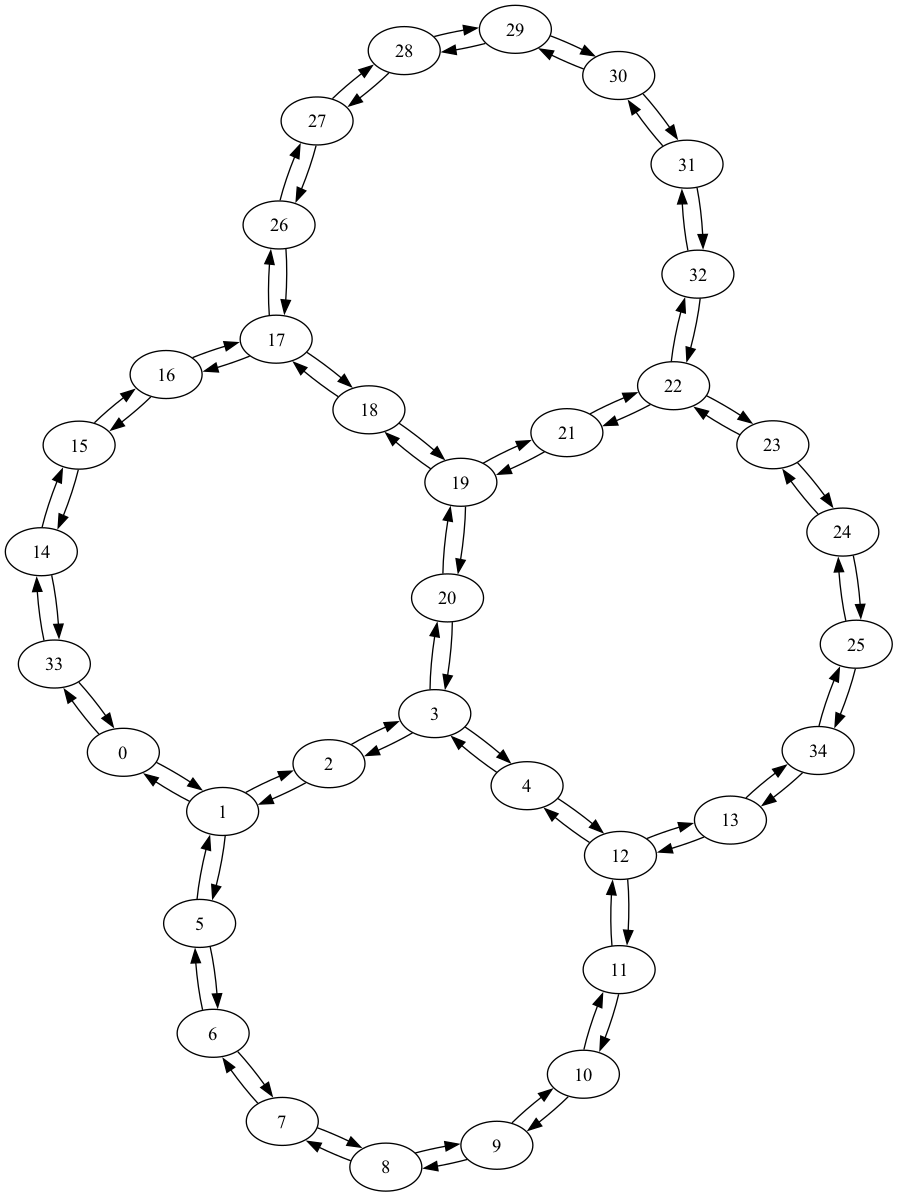

In [9]:
from rustworkx.visualization import graphviz_draw

reduced_map.draw()

In [82]:
def truncation(threshold, S):
    eigvals, eigvecs = np.linalg.eig(S)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    D = len(eigvals)
    truncated_eigvals = []
    truncated_eigvecs = []
    # make truncated matrix whose rows are eigenvectors of S with eigval above threshold
    for i in range(D):
        if eigvals[i] >= threshold:
            truncated_eigvals.append(eigvals[i])
            truncated_eigvecs.append(eigvecs[i])
    truncated_eigvals = np.array(truncated_eigvals)
    truncated_eigvecs = np.array(truncated_eigvecs).T
    print(len(truncated_eigvals))
    return truncated_eigvecs


def E_vs_D(H_tilde, S_tilde, threshold_slope):
    GSEs = []
    ground_states = []
    for d in range(1, len(S_tilde)+1):
        epsilon = threshold_slope*d
        H_temp = H_tilde[0:d, 0:d]
        S_temp = S_tilde[0:d, 0:d]
        V_eps = truncation(epsilon, S_temp)
        # solve GEVP
        A = V_eps.conj().T @ H_temp @ V_eps
        B = V_eps.conj().T @ S_temp @ V_eps
        E, c = scipy.linalg.eig(a=A, b=B)
        idx = E.argsort()[::-1]
        eigvals = E[idx]
        eigvecs = c[:, idx]
        GSEs.append(eigvals[-1])
        ground_states.append(eigvecs[:, -1])
        print(min(eigvals))

    return GSEs, ground_states, V_eps

## Run on (a noisy) simulator for comparison

In [74]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit import transpile
from qiskit_aer.primitives import EstimatorV2
# from qiskit_ibm_runtime import EstimatorV2
from qiskit import transpile
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from tqdm.notebook import tqdm

t_steps = 10
step_size=12
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)
H_tilde_sim_noisy = np.zeros([t_steps, t_steps], dtype=complex)
S_tilde_sim_noisy= np.zeros([t_steps, t_steps], dtype=complex)
delta_t = np.pi / step_size
num_shots = 800000

H = Heisenberg(1, num_data_qubits, edge_list)

basis_gates = backend.basis_gates


# initialize noisy simulator

simulator = EstimatorV2(
    options={
        "backend_options": {"method": "matrix_product_state"},
        "default_precision": 1 / np.sqrt(num_shots),
    }
)

time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

real_obs_H = SparsePauliOp("XX", 1) ^ H
imag_obs_H = SparsePauliOp("YX", 1) ^ H
real_obs_S = SparsePauliOp("XX", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)
imag_obs_S = SparsePauliOp("YX", 1) ^ SparsePauliOp("I" * num_data_qubits, 1)


for j in range(t_steps):
    for i in range(j + 1):
        m = i
        n = j - i
        qc = QuantumCircuit(35)
        qc.h(34)
        qc.h(33)
        qc = prep_psi_0(qc)
        for _ in range(n):
            qc.append(time_evol, range(num_data_qubits))
        qc = prep_psi_0_by_0(qc)
        for _ in range(m):
            qc.append(time_evol, range(num_data_qubits))
        circuits[i][j] = transpile(qc.copy().decompose(reps=1), basis_gates=basis_gates)



with tqdm(total=t_steps*t_steps) as pbar:
    for i in range(t_steps):
        for j in range(t_steps):
            if circuits[i][j] is not None:
                circ = circuits[i][j]
                layout = circ.layout
                obs=[real_obs_H, imag_obs_H,
                          real_obs_S, imag_obs_S]
                sim_job = simulator.run(
                [
                    (
                        circ, obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[0] + 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                    sim_job.result()[0].data.evs[2] + 1j * sim_job.result()[0].data.evs[3]
                )
            else:
                circ = circuits[j][i]
                layout = circ.layout
                obs=[real_obs_H.apply_layout(layout), imag_obs_H.apply_layout(layout),
                          real_obs_S.apply_layout(layout), imag_obs_S.apply_layout(layout)]
                sim_job = simulator.run(
                [
                    (
                        circ,obs
                    )
                ]
                )
                H_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[0] - 1j * sim_job.result()[0].data.evs[1]
                )
                S_tilde_sim_noisy[i, j] = (
                sim_job.result()[0].data.evs[2] - 1j * sim_job.result()[0].data.evs[3]
                )
            pbar.update(1)

        

  0%|          | 0/100 [00:00<?, ?it/s]

1
(20.03922927977238-0.016954135494283085j)
2
(18.22718055988382+0.04266357379816197j)
3
(17.831820716712507+0.06817575354099371j)
4
(17.80290861567229+0.06784321500793665j)
5
(17.78306864549422+0.05973217147836472j)
6
(17.72302994453028+0.03353286262202307j)
7
(17.636800714164885-0.0011988594224026734j)
8
(17.551881893847238+0.0015110518439684598j)
9
(17.42517913010569+0.014511535184949164j)
10
(17.37641350013743+0.019392450440254522j)


Text(0, 0.5, 'Ground state energy')

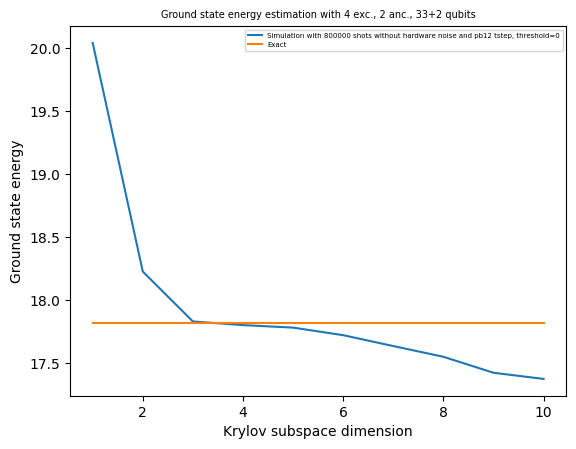

In [89]:
import matplotlib.pyplot as plt

threshold = 0
GSEs_sim_noisy,g_state,_ = E_vs_D(H_tilde_sim_noisy, S_tilde_sim_noisy,threshold)

plt.plot(
    list(range(1, t_steps + 1)),
         GSEs_sim_noisy,
    label=f"Simulation with {num_shots} shots without hardware noise and pb{step_size} tstep, threshold={threshold}",
)
plt.plot(
    list(range(1, t_steps+1)),
    17.818177984537805 * np.ones(t_steps),
    label="Exact",
)

plt.title("Ground state energy estimation with 4 exc., 2 anc., 33+2 qubits", fontsize=7)
plt.legend(fontsize = 5,loc="upper right")
plt.xlabel("Krylov subspace dimension")
plt.ylabel("Ground state energy")

#### Coefficients (amplitudes) of the ground state in Krylov basis

In [18]:
g_state[-1]

array([-0.02839312+0.13027536j, -0.31680529+0.12159007j,
       -0.26104081-0.08153693j, -0.31011168+0.16201982j,
       -0.54956867-0.17542309j, -0.00854932-0.39033428j,
        0.19719278+0.1869696j , -0.22934768+0.2412183j ])

## Exact diagonalisation for comparison

In [ ]:
# Method from Krylov tutorial
import itertools as it
import scipy as sp
from qiskit.quantum_info import Pauli
from tqdm.notebook import tqdm


def n_particle_gs(H_op, n_qubits, n_exc):
    """
    Find the ground state of the n particle(excitation) sector
    """
    H_x = []
    for p, coeff in H_op.to_list():
        H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

    H_z = []
    for p, coeff in H_op.to_list():
        H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

    H_c = H_op.coeffs

    n_exc = n_exc
    sub_dimn = int(sp.special.comb(n_qubits, n_exc))
    print("n_exc", n_exc, ", subspace dimension", sub_dimn)

    n_particle_H = np.zeros((sub_dimn, sub_dimn), dtype=complex)

    sparse_vecs = [
        set(vec) for vec in it.combinations(range(n_qubits), r=n_exc)
    ]  # list all of the possible sets of n_exc indices of 1s in n_exc-particle states

    with tqdm(total=len(sparse_vecs)*len(sparse_vecs)) as pbar:
        for i, i_set in enumerate(sparse_vecs):
            for j, j_set in enumerate(sparse_vecs):
                if len(i_set.symmetric_difference(j_set)) <= 2:

                    for p_x, p_z, coeff in zip(H_x, H_z, H_c):

                        if i_set.symmetric_difference(j_set) == p_x:
                            sgn = ((-1j) ** len(p_x.intersection(p_z))) * (
                            (-1) ** len(i_set.intersection(p_z))
                        )
                        else:
                            sgn = 0

                        n_particle_H[i, j] += sgn * coeff
                pbar.update(1)
    n_particle_H_sparse = sp.sparse.csr_array(n_particle_H)
    eige, eigv = sp.sparse.linalg.eigsh(n_particle_H_sparse, which='SA', k=1)
    print(eige)
   # eige, eigv = np.linalg.eigh(n_particle_H)
    gs_en = eige[0]  # min(eige)
    gs_vec = eigv[:, 0]
    print("n_exc particle ground state energy: ", gs_en)
    return gs_en, gs_vec, n_particle_H, sparse_vecs

# qubit_subset=(list(range(42, 48))
# + [35]
# + list(range(25, 30))
# + [36, 48, 49, 50, 54]
#   # + list(range(61, 66))
# +list(range(61, 66))
# + list(range(66, 70))
# + [56, 73, 82, 83, 84, 85, 86, 74])


# reduced_map = cm.reduce(qubit_subset)
# edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}

qubit_subset = (
    list(range(43, 48))
    + [35]
    + list(range(25, 30))
    + [36, 48, 49, 54]
   +list(range(61, 66)) + [55]
    + list(range(66, 70))
    + [56, 73, 82, 83, 84, 85, 86, 74, 42,50]
)


reduced_map = cm.reduce(qubit_subset)
edge_list = {(a, b) if a < b else (b, a) for a, b in list(reduced_map.get_edges())}
edge_list=edge_list - {(0,33),(14,33),(13,34),(25,34)}

H = Heisenberg(1, num_data_qubits, edge_list)
en, state, subspace_h, sp_vec= n_particle_gs(H,num_data_qubits, 4)

n_exc 4 , subspace dimension 40920


  0%|          | 0/1674446400 [00:00<?, ?it/s]

[-2.05824813]
n_exc particle ground state energy:  -2.0582481296104396


In [61]:
H = Heisenberg(1, num_data_qubits, edge_list)
H_x = []
for p, coeff in H.to_list():
    H_x.append(set([i for i, v in enumerate(Pauli(p).x) if v]))

H_z = []
for p, coeff in H.to_list():
    H_z.append(set([i for i, v in enumerate(Pauli(p).z) if v]))

print(H_x)
print(H_z)

[{28, 29}, {28, 29}, set(), {5, 6}, {5, 6}, set(), {16, 15}, {16, 15}, set(), {20, 28}, {20, 28}, set(), {19, 20}, {19, 20}, set(), {10, 11}, {10, 11}, set(), {9, 10}, {9, 10}, set(), {0, 1}, {0, 1}, set(), {24, 23}, {24, 23}, set(), {0, 10}, {0, 10}, set(), {14, 15}, {14, 15}, set(), {11, 13}, {11, 13}, set(), {4, 5}, {4, 5}, set(), {13, 14}, {13, 14}, set(), {26, 27}, {26, 27}, set(), {17, 18}, {17, 18}, set(), {8, 9}, {8, 9}, set(), {22, 23}, {22, 23}, set(), {32, 31}, {32, 31}, set(), {21, 22}, {21, 22}, set(), {30, 31}, {30, 31}, set(), {27, 31}, {27, 31}, set(), {6, 15}, {6, 15}, set(), {12, 13}, {12, 13}, set(), {3, 4}, {3, 4}, set(), {25, 26}, {25, 26}, set(), {8, 7}, {8, 7}, set(), {16, 17}, {16, 17}, set(), {2, 3}, {2, 3}, set(), {12, 29}, {12, 29}, set(), {20, 21}, {20, 21}, set(), {29, 30}, {29, 30}, set(), {24, 25}, {24, 25}, set(), {1, 2}, {1, 2}, set()]
[set(), {28, 29}, {28, 29}, set(), {5, 6}, {5, 6}, set(), {16, 15}, {16, 15}, set(), {20, 28}, {20, 28}, set(), {19, 20

### State fidelity analysis

In [90]:
from qiskit_aer.primitives import SamplerV2


t_steps=10
num_shots=800000
delta_t = np.pi / step_size
circuits = np.ndarray([t_steps, t_steps], dtype=QuantumCircuit)

time_evol = PauliEvolutionGate(H, time=delta_t, synthesis=synth)

simulator = SamplerV2(default_shots=num_shots,
                      options={
        "backend_options": {"method": "matrix_product_state"}}
)
dict={}
with tqdm(total=t_steps) as pbar:
    for j in range(t_steps):
        qc = QuantumCircuit(35)
        qc.h(34)
        qc.h(33)
        qc = prep_psi_0(qc)
        qc = prep_psi_0_by_0(qc)
        for _ in range(j):
           qc.append(time_evol, range(num_data_qubits))
        qc=transpile(qc.decompose(reps=1), basis_gates=basis_gates)
        qc.measure_all()
        sim_job = simulator.run([(qc)])
        snap = sim_job.result()[0].data.meas.get_counts()
        dict[(j)] = snap
        pbar.update(1)

  0%|          | 0/10 [00:00<?, ?it/s]

In [99]:
from typing import Dict

def construct_dict(dict:Dict, state_coeff:float, num_shots:int=num_shots)-> Dict:
    dct = {}
    for key,val in dict.items():
        if key[2:] in dct.keys():
            dct[key[2:]] += val/num_shots
        else:
            dct[key[2:]] = val/num_shots
        dct[key[2:]] = float(dct[key[2:]]*state_coeff)
    return dct

state_0_dict = construct_dict(dict[0],g_state[-1][0])
state_1_dict = construct_dict(dict[1],g_state[-1][1])
state_2_dict = construct_dict(dict[2],g_state[-1][2])
state_3_dict = construct_dict(dict[3],g_state[-1][3])
state_4_dict = construct_dict(dict[4],g_state[-1][4])
state_5_dict = construct_dict(dict[5],g_state[-1][5])
state_6_dict = construct_dict(dict[6],g_state[-1][6])
state_7_dict = construct_dict(dict[7],g_state[-1][7])
state_8_dict = construct_dict(dict[8],g_state[-1][8])
state_9_dict = construct_dict(dict[9],g_state[-1][9])

/var/folders/6p/67gfm43s19b12128lxx6vlzm0000gn/T/ipykernel_96661/2993902374.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  dct[key[2:]] = float(dct[key[2:]]*state_coeff)


In [100]:
from typing import List
def construct_master_dict(list_of_dicts:List[Dict])-> Dict:
    dct = {}
    for dict in list_of_dicts:
        for key,val in dict.items():
            if key in dct.keys():
                dct[key] += val
            else:
                dct[key] = val
    return dct

master_dict = construct_master_dict([state_0_dict,state_1_dict,state_2_dict,state_3_dict,
                                    state_4_dict,state_5_dict,state_6_dict,state_7_dict,
                                    state_8_dict,state_9_dict])

In [104]:
state_9_dict

{'000000001000000000000000001010010': 4.671067185906831e-05,
 '100000000000000100000010000000001': 8.308540834652502e-05,
 '001000000000001000100100000000000': 1.5268971197385115e-06,
 '001000100000000000100000000000001': 4.648306083573475e-06,
 '000000001000000000000000101000001': 7.749713305711853e-05,
 '000011000000000000000000001000100': 7.555872822943019e-07,
 '110000000000000000000000011000000': 8.357493700496977e-05,
 '000001000000000000100100010000000': 1.0497523596152152e-06,
 '000000001000000100010000000001000': 7.019676676666931e-06,
 '100000000000001000000000001000010': 2.655263312557338e-05,
 '000000000100000000000100001000100': 8.576785103557307e-06,
 '000000100000000000011000000001000': 1.5901106363733637e-06,
 '101000000000000101000000000000000': 3.968726545729825e-06,
 '001000000000000000000100010100000': 1.013317353680792e-05,
 '100000000000000000100010000100000': 0.00011259536258113776,
 '000000011000000000100000001000000': 3.2391371144205876e-06,
 '00000000010000000

In [107]:
bitstrings_list = []
for i in sp_vec:
    j,k,l,m =tuple(i)
    str = '0'*j + '1' + '0'*(k-1-j)+ '1' + '0'*(l-k-1) + '1' + '0'*(m-l-1) + '1'*(num_data_qubits-1-m)

    bitstrings_list.append(str[::-1])

In [108]:
from typing import Dict

def construct_exact_vec_dict(bitstrings_list, state=state)-> Dict:
    dct = {}
    for i,key in enumerate(bitstrings_list):
        dct[key] = state[i]
    return dct

dict_exact=construct_exact_vec_dict(bitstrings_list)

In [109]:
master_keys = master_dict.keys()

excluded_keys = [x for x in dict_exact.keys() if x not in master_dict.keys()]
print(f'number of excluded states {len(excluded_keys)}')
excluded_vals = [dict_exact[key] for key in excluded_keys]

sum([np.abs(x)**2 for x in excluded_vals])

number of excluded states 28089


np.float64(0.7381015252014628)